In [7]:
import pandas as pd

clean_path = r"C:\Users\Test\Desktop\intern\processed\cleaned_income_dataset.csv"

df = pd.read_csv(clean_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Shape: (6500, 5)


,Country,Year,Gini_Index,Education_Spending_%GDP,Unemployment_%
0,Brazil,2015,41.188583,4.981644,6.189960
1,India,2017,28.742018,4.883997,7.355132
2,Brazil,2004,29.623825,4.041603,4.801137
3,Brazil,2021,41.441344,4.038214,6.612803
4,India,2003,33.749351,4.085419,6.730546


In [8]:
num_cols = ['Gini_Index', 'Education_Spending_%GDP', 'Unemployment_%']
cat_cols = ['Country']

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Gini_Index', 'Education_Spending_%GDP', 'Unemployment_%']
Categorical: ['Country']


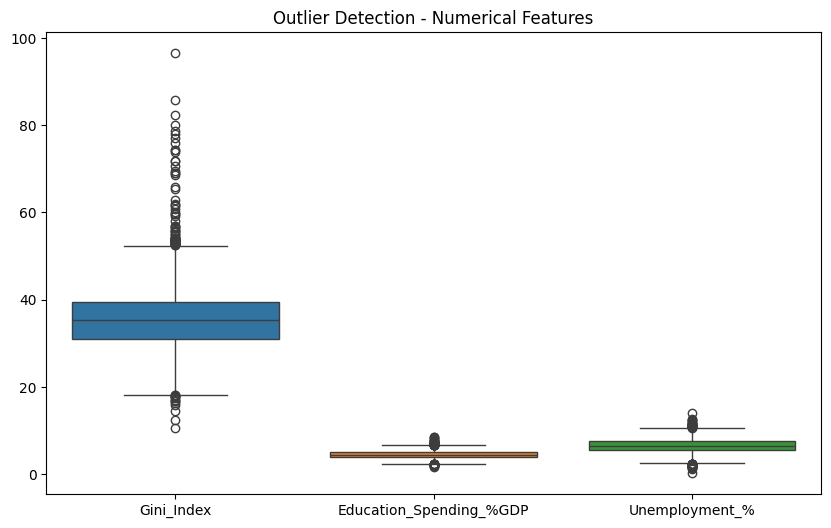

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title("Outlier Detection - Numerical Features")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print("Scaling Completed")
df_scaled.head()

Scaling Completed


,Country,Year,Gini_Index,Education_Spending_%GDP,Unemployment_%
0,Brazil,2015,0.842549,0.527072,-0.268673
1,India,2017,-0.999993,0.407309,0.489238
2,Brazil,2004,-0.869453,-0.625874,-1.172062
3,Brazil,2021,0.879966,-0.630030,0.006374
4,India,2003,-0.258727,-0.572135,0.082963


In [11]:
df_encoded = pd.get_dummies(df_scaled, columns=['Country'], drop_first=True)

print("Encoding Completed")
print("New Shape:", df_encoded.shape)

df_encoded.head()

Encoding Completed
New Shape: (6500, 14)


,Year,Gini_Index,Education_Spending_%GDP,Unemployment_%,Country_Canada,Country_China,Country_France,Country_Germany,Country_India,Country_Indonesia,Country_Japan,Country_South Africa,Country_UK,Country_USA
0,2015,0.842549,0.527072,-0.268673,False,False,False,False,False,False,False,False,False,False
1,2017,-0.999993,0.407309,0.489238,False,False,False,False,True,False,False,False,False,False
2,2004,-0.869453,-0.625874,-1.172062,False,False,False,False,False,False,False,False,False,False
3,2021,0.879966,-0.630030,0.006374,False,False,False,False,False,False,False,False,False,False
4,2003,-0.258727,-0.572135,0.082963,False,False,False,False,True,False,False,False,False,False


In [12]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     6500 non-null   int64  
 1   Gini_Index               6500 non-null   float64
 2   Education_Spending_%GDP  6500 non-null   float64
 3   Unemployment_%           6500 non-null   float64
 4   Country_Canada           6500 non-null   bool   
 5   Country_China            6500 non-null   bool   
 6   Country_France           6500 non-null   bool   
 7   Country_Germany          6500 non-null   bool   
 8   Country_India            6500 non-null   bool   
 9   Country_Indonesia        6500 non-null   bool   
 10  Country_Japan            6500 non-null   bool   
 11  Country_South Africa     6500 non-null   bool   
 12  Country_UK               6500 non-null   bool   
 13  Country_USA              6500 non-null   bool   
dtypes: bool(10), float64(3),

In [ ]:
# Define save path for Stage 2
stage2_path = r"C:\Users\Test\Desktop\intern\processed"

# Save file
df_encoded.to_csv(stage2_path, index=False)

# Confirm save
rows, cols = df_encoded.shape
print("Stage 2 Preprocessed Dataset Saved Successfully!")
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")